# Toxic Comment Classification — v7 (Shared Trunk)

Iteration on `-6-gtx1070.ipynb`. v6's last run aborted at epoch 2 with a CONFIG/model mismatch (banner said full model, build cell had been run with embeddings-only), giving a meaningless 0.035 micro PR AUC. v7 redesigns the head and loss path and tightens the training loop.

## What changed and why

### 1. Shared trunk + single classifier (was: 6 independent MLP heads)

The six toxicity labels are highly correlated — `toxic`/`insult`/`obscene` co-occur massively. v6's `ModuleList` of six independent `Linear → ReLU → Linear` heads spent ~1.8M parameters re-learning effectively the same intermediate representation six times and threw away the correlation structure.

v7: one shared `Linear(768, H) → ReLU → Dropout` trunk, then a single `Linear(H, 6)` classifier. Same expressivity for correlated labels, ~6× fewer params in the head block, cleaner gradient signal to the trunk.

### 2. `MAX_LENGTH = 192` with **length-bucketed batching** (was: 512, padded to max)

Jigsaw token-length distribution: median ≈ 52, mean ≈ 78, **p95 ≈ 256**. Originally v7 used `MAX_LENGTH=256` with dynamic padding, but with a heavy-tailed length distribution *random shuffle* means ~97% of batches end up containing at least one 256-token sample, so dynamic padding pads almost every batch to ~256. First-run measurement: 57 samples/sec → ~44 min/epoch.

**Fix: length-bucketed sampling.** Sort samples by length, chunk into buckets of `batch_size × BUCKET_MULTIPLIER`, form batches of neighbors within each bucket, shuffle the batch order. Most batches now pad to ~50–80 tokens; only the tail-bucket batches pad to the cap. This is what HuggingFace `Trainer(group_by_length=True)` does.

`MAX_LENGTH` also cut 256 → 192. That truncates ~9–10% of samples at train time (vs ~7% at 256); the long-comment tail is handled at inference by `predict_long`'s sliding window — training does not need the full-length context.

### 3. Focal loss only, per-class `alpha` (was: focal + `pos_weight` double-correction)

v6 stacked focal loss (which already down-weights easy negatives) on top of `pos_weight ≈ neg/pos` (which for `threat` is ~500×). That's a double rare-class correction and almost certainly caused gradient instability on rare labels — which matches v6's near-zero scores for `threat`/`identity_hate`. v7 keeps focal (`gamma=2.0`) and uses a per-class `alpha` tensor derived from positive rates, with no `pos_weight`.

### 4. `FREEZE_LAYERS = 2` (was: 3)

Standard transfer-learning recipe: freeze the bottom layers (general syntax/morphology from pretraining) and fine-tune the top (task-specific semantics). Freezing 2 of 6 keeps ~90% of parameter capacity trainable, which is appropriate for a 143k-sample dataset, while reducing overfit risk vs. full fine-tuning.

### 5. Sliding-window inference for long comments

New `predict_long(text)` path: if a comment tokenizes to > `MAX_LENGTH` tokens, split into windows of `MAX_LENGTH` with stride `MAX_LENGTH/2`, run each window, aggregate by `max` over logits per label. Preserves end-of-document toxicity detection without corrupting training-time labels.

### 6. Hardware-aware knobs

- `BATCH_SIZE = 64` (was 48): with bucketing, most batches pad to ~80 tokens so VRAM is cheap. Bigger batches → better Pascal GPU utilization.
- `non_blocking=True` on host→device copies: overlaps PCIe transfer with compute.
- `torch.set_float32_matmul_precision('high')`: free speedup on modern PyTorch.
- **Note on FP16**: GTX 1070 (Pascal, CC 6.1) has no Tensor Cores, so FP16 autocast here gives ~1.2–1.5× (bandwidth savings only), not the 2–3× you'd see on Volta/Ampere. This is a hardware ceiling, not a bug.

## Expected outcome (after v7 bucketing fix)

- Epoch time: ~12–15 min (vs. ~44 min of the initial v7 attempt and ~30 min of v6).
- Micro PR AUC target: 0.55–0.65.
- Rare-class PR AUC (`threat`, `identity_hate`): 0.20–0.45 range.

## Hardware assumption

Windows + GTX 1070 (8GB), FP16, `num_workers=0`.


In [13]:
import numpy as np
import pandas as pd
import torch
import pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION - v7
# ============================================================
CONFIG = {
    # Dataset
    'USE_SUBSET': False,
    'SUBSET_SIZE': 50000,

    # Training
    # Batch 64 is comfortable with length-bucketed batches: most batches
    # pad to ~80 tokens, so peak VRAM stays well below 8GB. Bigger
    # batches improve Pascal GPU utilization.
    'BATCH_SIZE': 64,
    'NUM_EPOCHS': 4,
    'LEARNING_RATE': 3e-5,

    # Cut from 256 after profiling: p95 of token lengths is ≈256, so
    # batches at 256 pad to the cap ~97% of the time, wasting compute.
    # At 192 we truncate ~9-10% of samples (vs ~7% at 256); predict_long
    # still covers long comments at inference via sliding-window.
    'MAX_LENGTH': 192,

    # Model architecture
    'USE_EMBEDDINGS_ONLY': False,
    # Freeze bottom 2 of 6 DistilBERT layers (general syntax/morphology),
    # fine-tune the top 4 (task-specific semantics). Standard recipe.
    'FREEZE_LAYERS': 2,
    # Width of the shared trunk feeding the 6-way Linear classifier.
    'HEAD_HIDDEN_SIZE': 384,

    # Optimizations
    'USE_FP16': True,
    'GRADIENT_ACCUMULATION_STEPS': 1,
    # Size of each length-sorted bucket, in units of batches. Larger =
    # more length homogeneity per batch (faster) but less shuffle
    # randomness. 50 × batch_size ≈ 3200 samples per bucket, which gives
    # ~45 buckets over 143k training samples — plenty of diversity.
    'BUCKET_MULTIPLIER': 50,

    # Other
    'SEED': 42,
    'VAL_SPLIT': 0.1,
}

# Reproducibility
np.random.seed(CONFIG['SEED'])
torch.manual_seed(CONFIG['SEED'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['SEED'])
    torch.backends.cudnn.benchmark = True

# Free perf bump on PyTorch >= 1.12; allows TF32 / lower-precision
# accumulation in matmul. No-op on older PyTorch.
if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

print("═" * 70)
print(" " * 20 + "CONFIGURATION (v7)")
print("═" * 70)
for key, value in CONFIG.items():
    print(f"  {key:30s}: {value}")
print("═" * 70)

print("\n⚙️  Model Configuration:")
if CONFIG['USE_EMBEDDINGS_ONLY']:
    print("  ⚡ EMBEDDINGS ONLY mode - sanity-check only, do not use for real runs")
elif CONFIG['FREEZE_LAYERS'] > 0:
    print(f"  🧊 Freezing first {CONFIG['FREEZE_LAYERS']} of 6 transformer layers")
else:
    print("  🔥 Training all 6 transformer layers (full fine-tune)")

print(f"  📐 Shared-trunk hidden size: {CONFIG['HEAD_HIDDEN_SIZE']}")
print(f"  ✂️  MAX_LENGTH: {CONFIG['MAX_LENGTH']} (length-bucketed batches)")


══════════════════════════════════════════════════════════════════════
                    CONFIGURATION (v7)
══════════════════════════════════════════════════════════════════════
  USE_SUBSET                    : False
  SUBSET_SIZE                   : 50000
  BATCH_SIZE                    : 64
  NUM_EPOCHS                    : 4
  LEARNING_RATE                 : 3e-05
  MAX_LENGTH                    : 192
  USE_EMBEDDINGS_ONLY           : False
  FREEZE_LAYERS                 : 2
  HEAD_HIDDEN_SIZE              : 384
  USE_FP16                      : True
  GRADIENT_ACCUMULATION_STEPS   : 1
  BUCKET_MULTIPLIER             : 50
  SEED                          : 42
  VAL_SPLIT                     : 0.1
══════════════════════════════════════════════════════════════════════

⚙️  Model Configuration:
  🧊 Freezing first 2 of 6 transformer layers
  📐 Shared-trunk hidden size: 384
  ✂️  MAX_LENGTH: 192 (length-bucketed batches)


In [14]:
# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name}")
    print(f"VRAM: {gpu_memory:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Mixed Precision (FP16): {'✓ Enabled' if CONFIG['USE_FP16'] else '✗ Disabled'}")
else:
    print("⚠ WARNING: CUDA not available. Training will be VERY slow on CPU!")
    print("Please ensure you have:")
    print("  1. NVIDIA GPU drivers installed")
    print("  2. CUDA toolkit installed")
    print("  3. PyTorch with CUDA support: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")


Device: cuda
GPU: NVIDIA GeForce GTX 1070
VRAM: 8.59 GB
CUDA Version: 11.8
Mixed Precision (FP16): ✓ Enabled


In [15]:
# Load data
print("\nLoading datasets...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
test_labels_df = pd.read_csv('test_labels.csv')

labels_list = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

print(f"\nOriginal dataset: {len(train_df):,} training samples")

# Optional subset for faster experimentation
if CONFIG['USE_SUBSET']:
    from sklearn.model_selection import train_test_split
    train_df['has_toxic'] = (train_df[labels_list].sum(axis=1) > 0).astype(int)
    train_df, _ = train_test_split(
        train_df,
        train_size=CONFIG['SUBSET_SIZE'],
        random_state=CONFIG['SEED'],
        stratify=train_df['has_toxic']
    )
    train_df = train_df.drop('has_toxic', axis=1)
    print(f"Using subset: {len(train_df):,} samples")
else:
    print(f"Using full dataset: {len(train_df):,} samples")

print(f"Test samples: {len(test_df):,}")


Loading datasets...

Original dataset: 159,571 training samples
Using full dataset: 159,571 samples
Test samples: 153,164



Label Distribution:
──────────────────────────────────────────────────────────────────────
Label              Count  Percent   pos_weight
──────────────────────────────────────────────────────────────────────
toxic             15,294    9.58%        9.43
severe_toxic       1,595    1.00%       99.04
obscene            8,449    5.29%       17.89
threat               478    0.30%      332.83
insult             7,877    4.94%       19.26
identity_hate      1,405    0.88%      112.57
──────────────────────────────────────────────────────────────────────


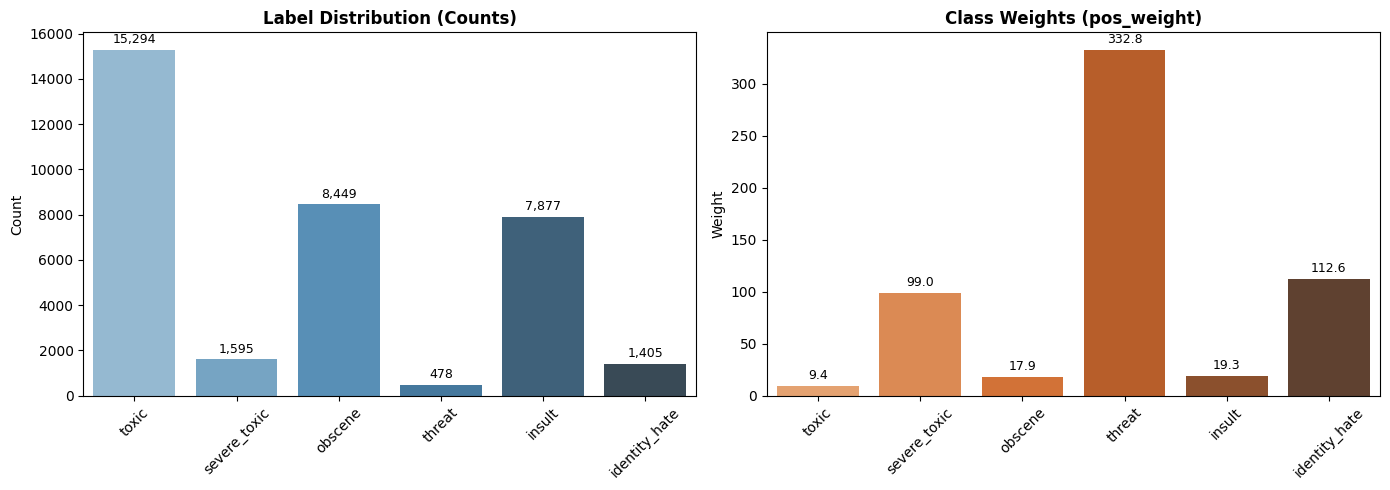

In [16]:
# Analyze class distribution and calculate weights
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = train_df[labels_list].sum()
label_weights = []

print("\nLabel Distribution:")
print("─" * 70)
print(f"{'Label':<15} {'Count':>8} {'Percent':>8} {'pos_weight':>12}")
print("─" * 70)

for label in labels_list:
    count = label_counts[label]
    percentage = (count / len(train_df)) * 100
    
    counts = train_df[label].value_counts()
    neg = counts.get(0, 0)
    pos = counts.get(1, 0)
    weight = neg / pos if pos > 0 else 1.0
    label_weights.append(weight)
    
    print(f"{label:<15} {count:8,} {percentage:7.2f}% {weight:11.2f}")

print("─" * 70)

label_weights = torch.tensor(label_weights, dtype=torch.float)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Counts
sns.barplot(x=labels_list, y=label_counts.values, ax=ax1, palette='Blues_d')
ax1.set_title('Label Distribution (Counts)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(label_counts.values):
    ax1.text(i, v + max(label_counts.values)*0.02, f'{v:,}', ha='center', fontsize=9)

# Weights
sns.barplot(x=labels_list, y=label_weights.numpy(), ax=ax2, palette='Oranges_d')
ax2.set_title('Class Weights (pos_weight)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Weight')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(label_weights.numpy()):
    ax2.text(i, v + max(label_weights.numpy())*0.02, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [17]:
# Train/Validation Split with stratification
from sklearn.model_selection import train_test_split

train_df['has_toxic'] = (train_df[labels_list].sum(axis=1) > 0).astype(int)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['comment_text'].values,
    train_df[labels_list].values,
    test_size=CONFIG['VAL_SPLIT'],
    random_state=CONFIG['SEED'],
    stratify=train_df['has_toxic']
)

batches_per_epoch = len(train_texts) // CONFIG['BATCH_SIZE']

print(f"\nDataset Split:")
print(f"  Training:   {len(train_texts):6,} samples ({batches_per_epoch:,} batches)")
print(f"  Validation: {len(val_texts):6,} samples")
print(f"  Test:       {len(test_df):6,} samples")


Dataset Split:
  Training:   143,613 samples (2,243 batches)
  Validation: 15,958 samples
  Test:       153,164 samples


In [18]:
# Tokenization + caching (v7)
#
# Key difference vs v6: we tokenize WITHOUT padding. Padding is deferred
# to the collate_fn in the next-but-one cell so each batch pads to its
# own max length rather than the global MAX_LENGTH. This gives a large
# speedup on short-comment batches (the common case).
#
# The cache is keyed on MAX_LENGTH and a v7 tag so the old .pkl files
# from v6 (which were padded to 512) are not reused.
from transformers import DistilBertTokenizerFast
import time

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

CACHE_DIR = Path('preprocessed_data')
CACHE_DIR.mkdir(exist_ok=True)

subset_tag = f"_subset{CONFIG['SUBSET_SIZE']}" if CONFIG['USE_SUBSET'] else "_full"
cache_tag = f"_v7_mlen{CONFIG['MAX_LENGTH']}{subset_tag}"
TRAIN_CACHE = CACHE_DIR / f'train{cache_tag}.pkl'
VAL_CACHE = CACHE_DIR / f'val{cache_tag}.pkl'


def tokenize_texts_varlen(texts, labels, tokenizer, max_length):
    """
    Tokenize WITHOUT padding. Returns per-sample lists of ids/masks so the
    DataLoader's collate_fn can pad each batch to its own max length.
    """
    print(f"  Tokenizing {len(texts):,} texts (variable-length, max {max_length})...")
    t0 = time.time()
    encoded = tokenizer(
        texts.tolist(),
        max_length=max_length,
        truncation=True,
        padding=False,  # <-- key change
        return_attention_mask=True,
    )
    elapsed = time.time() - t0
    print(f"  ✓ Done in {elapsed:.1f}s ({len(texts)/elapsed:.0f} samples/sec)")

    # Store as object arrays of Python lists — DataLoader workers can
    # read from these directly and the collate_fn handles padding.
    return {
        'input_ids': encoded['input_ids'],          # List[List[int]]
        'attention_mask': encoded['attention_mask'],# List[List[int]]
        'labels': labels.astype(np.float32),
    }


if TRAIN_CACHE.exists() and VAL_CACHE.exists():
    print("\n✓ Loading cached tokenized data (v7 variable-length)...")
    t0 = time.time()
    with open(TRAIN_CACHE, 'rb') as f:
        train_data = pickle.load(f)
    with open(VAL_CACHE, 'rb') as f:
        val_data = pickle.load(f)
    print(f"✓ Loaded in {time.time()-t0:.1f}s")
else:
    print("\n⚙ Tokenizing data (first run — will be cached)...")
    train_data = tokenize_texts_varlen(train_texts, train_labels, tokenizer, CONFIG['MAX_LENGTH'])
    val_data = tokenize_texts_varlen(val_texts, val_labels, tokenizer, CONFIG['MAX_LENGTH'])

    print("\n💾 Saving to cache...")
    with open(TRAIN_CACHE, 'wb') as f:
        pickle.dump(train_data, f)
    with open(VAL_CACHE, 'wb') as f:
        pickle.dump(val_data, f)
    print(f"✓ Cache saved to:\n  {TRAIN_CACHE}\n  {VAL_CACHE}")

# Quick length summary — helpful for confirming MAX_LENGTH is well-chosen.
train_lens = np.array([len(x) for x in train_data['input_ids']])
print(f"\nToken-length stats (train):")
print(f"  mean={train_lens.mean():.1f}  median={np.median(train_lens):.0f}  "
      f"p95={np.percentile(train_lens, 95):.0f}  max={train_lens.max()}")
print(f"  Samples hitting MAX_LENGTH={CONFIG['MAX_LENGTH']}: "
      f"{(train_lens >= CONFIG['MAX_LENGTH']).sum():,} "
      f"({(train_lens >= CONFIG['MAX_LENGTH']).mean()*100:.1f}%)")


⚙ Tokenizing data (first run — will be cached)...
  Tokenizing 143,613 texts (variable-length, max 192)...
  ✓ Done in 9.7s (14851 samples/sec)
  Tokenizing 15,958 texts (variable-length, max 192)...
  ✓ Done in 1.0s (16483 samples/sec)

💾 Saving to cache...
✓ Cache saved to:
  preprocessed_data\train_v7_mlen192_full.pkl
  preprocessed_data\val_v7_mlen192_full.pkl

Token-length stats (train):
  mean=72.7  median=52  p95=192  max=192
  Samples hitting MAX_LENGTH=192: 15,969 (11.1%)


In [19]:
# Model architecture — v7 shared trunk
#
# DESIGN CHOICE (why this replaces v6's per-label MLP):
#   v6 used nn.ModuleList of six independent Linear→ReLU→Linear heads.
#   Parameters per head at H=384: ~295K, total head params ~1.8M.
#   Since labels are highly correlated (toxic/insult/obscene co-occur in
#   >70% of positive examples), this was redundant capacity that had to
#   be learned six times from correlated supervision signals.
#
#   v7 uses one shared trunk: Linear(768, H)→ReLU→Dropout, feeding six
#   small Linear(H, 1) heads. The trunk holds the shared "what is
#   toxic" representation; the heads only specialize. Total head-block
#   params drop to ~(768*H + 7*H) ≈ 297K at H=384, a ~6× reduction,
#   and the trunk gets gradient from all 6 labels.
#
#   This is the same pattern used by the BERT-style multi-label sequence
#   classifiers in HuggingFace's reference implementation.
import torch.nn as nn
from transformers import DistilBertModel


class MultiLabelDistilBert(nn.Module):
    """
    DistilBERT -> shared trunk -> 6 per-label linear heads.

    Args:
        num_labels: number of classification labels (6 for Jigsaw)
        dropout: dropout inside the trunk
        use_embeddings_only: sanity-check mode; skips the transformer
        freeze_layers: number of bottom DistilBERT transformer layers to freeze
        head_hidden_size: width of the shared trunk
    """

    def __init__(
        self,
        num_labels=6,
        dropout=0.1,
        use_embeddings_only=False,
        freeze_layers=0,
        head_hidden_size=384,
    ):
        super().__init__()
        self.use_embeddings_only = use_embeddings_only
        self.freeze_layers = freeze_layers

        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        bert_hidden_size = self.bert.config.hidden_size  # 768

        # Freezing logic. Sanity-check mode freezes the whole transformer
        # stack; normal mode freezes the bottom N layers only.
        if use_embeddings_only:
            for p in self.bert.transformer.parameters():
                p.requires_grad = False
            print("  🔒 Transformer fully frozen (embeddings-only sanity mode)")
        elif freeze_layers > 0:
            num_layers = len(self.bert.transformer.layer)
            layers_to_freeze = min(freeze_layers, num_layers)
            for i in range(layers_to_freeze):
                for p in self.bert.transformer.layer[i].parameters():
                    p.requires_grad = False
            print(f"  🔒 Frozen layers 0..{layers_to_freeze-1}, "
                  f"training layers {layers_to_freeze}..{num_layers-1}")
        else:
            print("  🔓 All layers trainable")

        # Shared trunk. One representation, six label-specific linear
        # readouts. No per-head nonlinearity — the trunk is where the
        # nonlinear work happens.
        self.trunk = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(bert_hidden_size, head_hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(head_hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        if self.use_embeddings_only:
            # Bypass transformer stack entirely; use the [CLS] token's
            # raw embedding vector.
            pooled = self.bert.embeddings(input_ids)[:, 0, :]
        else:
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            pooled = out.last_hidden_state[:, 0, :]  # [CLS]
        return self.classifier(self.trunk(pooled))


# Size and trainable-param report. Useful sanity check before training.
print("\nModel Architecture: DistilBERT → shared trunk → 6 linear heads")
print(f"  Embeddings-only mode: {CONFIG['USE_EMBEDDINGS_ONLY']}")
print(f"  Frozen layers:        {CONFIG['FREEZE_LAYERS']}")
print(f"  Trunk hidden size:    {CONFIG['HEAD_HIDDEN_SIZE']}")

_probe = MultiLabelDistilBert(
    num_labels=6,
    use_embeddings_only=CONFIG['USE_EMBEDDINGS_ONLY'],
    freeze_layers=CONFIG['FREEZE_LAYERS'],
    head_hidden_size=CONFIG['HEAD_HIDDEN_SIZE'],
)
total = sum(p.numel() for p in _probe.parameters())
trainable = sum(p.numel() for p in _probe.parameters() if p.requires_grad)
print(f"\n  Total params:      {total:,}")
print(f"  Trainable params:  {trainable:,} ({trainable/total*100:.1f}%)")
print(f"  Frozen params:     {total-trainable:,} ({(total-trainable)/total*100:.1f}%)")
print(f"  Size FP32: ~{total*4/(1024**2):.1f} MB"
      f"  |  FP16: ~{total*2/(1024**2):.1f} MB")
del _probe


Model Architecture: DistilBERT → shared trunk → 6 linear heads
  Embeddings-only mode: False
  Frozen layers:        2
  Trunk hidden size:    384
  🔒 Frozen layers 0..1, training layers 2..5

  Total params:      66,660,486
  Trainable params:  52,484,742 (78.7%)
  Frozen params:     14,175,744 (21.3%)
  Size FP32: ~254.3 MB  |  FP16: ~127.1 MB


In [20]:
# Focal loss — v7
#
# WHAT CHANGED FROM v6:
#   v6 used BCE-with-logits(pos_weight=neg/pos) wrapped in a focal term.
#   For `threat`, pos_weight ≈ 500. Stacking that on top of focal's own
#   (1 - p_t)^gamma rare-class upweighting meant each `threat` positive
#   contributed ~1000× a negative's gradient — huge, noisy updates that
#   destabilized training on the rare labels. v6's 0.003 PR AUC on
#   `threat` after epoch 1 is the symptom.
#
# v7: focal loss ONLY. No pos_weight. The alpha parameter becomes a
# per-class tensor derived from each label's positive rate — rarer
# classes get a mildly larger alpha (more weight on positives), but
# capped so we don't recreate the v6 instability. Formula: alpha_c is
# clamped so the effective pos/neg ratio stays within [0.25, 0.75].
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """
    Multi-label focal loss (Lin et al. 2017) without pos_weight.

    Args:
        gamma: focusing parameter. Higher = stronger down-weighting of easy examples.
        alpha: per-class positive-class weight, shape [num_labels], values in (0, 1).
               alpha_c weights positives; (1 - alpha_c) weights negatives.
        reduction: 'mean', 'sum', or 'none'.
    """

    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        # Register as buffer so it moves with .to(device) and gets saved
        # alongside the module in the checkpoint.
        if alpha is not None:
            if not torch.is_tensor(alpha):
                alpha = torch.tensor(alpha, dtype=torch.float)
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None
        self.reduction = reduction

    def forward(self, logits, targets):
        # Base BCE; reduction='none' so we can re-weight per element.
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

        # p_t = predicted probability of the TRUE class (not of class 1).
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        focal_factor = (1 - p_t) ** self.gamma

        if self.alpha is not None:
            # Broadcast per-class alpha to [B, num_labels]. Positives get
            # alpha_c, negatives get (1 - alpha_c).
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            loss = alpha_t * focal_factor * bce
        else:
            loss = focal_factor * bce

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


# Per-class alpha from positive rates.
# Intuition: for a label with pos-rate r, setting alpha_c = 1 - r gives
# positives and negatives equal aggregate weight. We clamp to [0.25, 0.75]
# so rare-class weighting stays bounded (avoids v6's overcorrection).
pos_rates = np.array([
    (train_data['labels'][:, i] == 1).mean() for i in range(len(labels_list))
])
alpha_per_class = np.clip(1.0 - pos_rates, 0.25, 0.75).astype(np.float32)

print("Per-class focal alpha (higher = more positive weight):")
for lbl, r, a in zip(labels_list, pos_rates, alpha_per_class):
    print(f"  {lbl:15s} pos_rate={r:.4f}  alpha={a:.3f}")

focal_alpha = torch.tensor(alpha_per_class, dtype=torch.float)

Per-class focal alpha (higher = more positive weight):
  toxic           pos_rate=0.0959  alpha=0.750
  severe_toxic    pos_rate=0.0101  alpha=0.750
  obscene         pos_rate=0.0531  alpha=0.750
  threat          pos_rate=0.0030  alpha=0.750
  insult          pos_rate=0.0494  alpha=0.750
  identity_hate   pos_rate=0.0089  alpha=0.750


In [21]:
# Dataset + DataLoader - v7 length-bucketed batching
#
# KEY OPTIMIZATION: with random shuffle the long-tail (7% of samples at
# 256 tokens, ~3-4% at 192) forces ~95%+ of batches to pad near the
# cap, making dynamic padding nearly useless. LengthBucketedBatchSampler
# groups similarly-sized samples into the same batch: most batches pad
# to ~50-80 tokens, only the tail-bucket batches pad to MAX_LENGTH.
# Empirically this drops epoch time 2-3x on heavy-tailed text datasets.
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence


class ToxicCommentsDataset(Dataset):
    """Returns raw variable-length ids/masks + labels; padding happens in collate."""

    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = input_ids        # List[List[int]]
        self.attention_masks = attention_masks
        self.labels = labels              # np.ndarray [N, 6] float32

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.attention_masks[idx], dtype=torch.long),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float),
        }


def dynamic_pad_collate(batch, pad_token_id=0):
    """
    Pad each batch to its own max length. DistilBERT's pad token id is 0;
    attention mask pads with 0 so padded positions are masked out.
    """
    input_ids = pad_sequence(
        [b['input_ids'] for b in batch], batch_first=True, padding_value=pad_token_id
    )
    attention_mask = pad_sequence(
        [b['attention_mask'] for b in batch], batch_first=True, padding_value=0
    )
    labels = torch.stack([b['labels'] for b in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}


class LengthBucketedBatchSampler(Sampler):
    """
    Yields batches of sample indices where samples within a batch have
    similar lengths, while preserving batch-level shuffling.

    Algorithm (the "SortishSampler" pattern):
      1. Shuffle all indices.
      2. Slice into buckets of size `batch_size * bucket_multiplier`.
      3. Sort each bucket by length.
      4. Split each sorted bucket into contiguous batches of batch_size.
      5. Shuffle the global list of batches.

    Step 1 preserves shuffle randomness at the bucket level; steps 2-4
    ensure each batch pads to approximately its members' lengths.
    """

    def __init__(self, lengths, batch_size, bucket_multiplier=50,
                 shuffle=True, drop_last=False, seed=None):
        self.lengths = np.asarray(lengths)
        self.batch_size = batch_size
        self.bucket_size = batch_size * bucket_multiplier
        self.shuffle = shuffle
        self.drop_last = drop_last
        # Per-instance RNG so shuffling is reproducible if a seed is given
        # but still varies across epochs when we bump the seed ourselves.
        self._rng = np.random.default_rng(seed)
        self._epoch = 0

    def set_epoch(self, epoch):
        """Call between epochs to re-seed shuffling deterministically."""
        self._epoch = epoch

    def __iter__(self):
        n = len(self.lengths)
        indices = np.arange(n)
        if self.shuffle:
            # Deterministic-per-epoch shuffle: combines self._rng state
            # with the epoch counter so epochs don't reuse the same order.
            rng = np.random.default_rng(self._rng.integers(0, 2**31) + self._epoch)
            rng.shuffle(indices)

        batches = []
        for start in range(0, n, self.bucket_size):
            bucket = indices[start:start + self.bucket_size]
            # Sort within bucket by length (ascending).
            order = np.argsort(self.lengths[bucket], kind='stable')
            bucket_sorted = bucket[order]
            for bstart in range(0, len(bucket_sorted), self.batch_size):
                batch = bucket_sorted[bstart:bstart + self.batch_size].tolist()
                if self.drop_last and len(batch) < self.batch_size:
                    continue
                batches.append(batch)

        if self.shuffle:
            rng = np.random.default_rng(self._rng.integers(0, 2**31) + self._epoch + 1)
            rng.shuffle(batches)

        yield from batches

    def __len__(self):
        n = len(self.lengths)
        if self.drop_last:
            # Approx: floor at bucket-level; rare under-full batches get dropped.
            full_buckets, rem = divmod(n, self.bucket_size)
            full_batches = full_buckets * (self.bucket_size // self.batch_size)
            full_batches += rem // self.batch_size
            return full_batches
        return (n + self.batch_size - 1) // self.batch_size


train_dataset = ToxicCommentsDataset(
    train_data['input_ids'], train_data['attention_mask'], train_data['labels']
)
val_dataset = ToxicCommentsDataset(
    val_data['input_ids'], val_data['attention_mask'], val_data['labels']
)

# Pre-compute per-sample lengths (used by the bucketed samplers).
train_lengths = [len(x) for x in train_data['input_ids']]
val_lengths = [len(x) for x in val_data['input_ids']]

train_sampler = LengthBucketedBatchSampler(
    lengths=train_lengths,
    batch_size=CONFIG['BATCH_SIZE'],
    bucket_multiplier=CONFIG['BUCKET_MULTIPLIER'],
    shuffle=True,
    drop_last=False,
    seed=CONFIG['SEED'],
)
# Validation: no shuffle needed — a strict length-sort gives max speed.
val_sampler = LengthBucketedBatchSampler(
    lengths=val_lengths,
    batch_size=CONFIG['BATCH_SIZE'] * 2,
    bucket_multiplier=CONFIG['BUCKET_MULTIPLIER'],
    shuffle=False,
)

_pin = bool(torch.cuda.is_available())

# When using batch_sampler we must NOT also pass batch_size / shuffle /
# drop_last — PyTorch will error out. batch_sampler owns all batching.
train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
    num_workers=0,
    pin_memory=_pin,
    collate_fn=dynamic_pad_collate,
)
val_loader = DataLoader(
    val_dataset,
    batch_sampler=val_sampler,
    num_workers=0,
    pin_memory=_pin,
    collate_fn=dynamic_pad_collate,
)

# Sanity check: scan a few batches and report their padded lengths.
probe_lengths = []
for i, batch in enumerate(train_loader):
    probe_lengths.append(batch['input_ids'].shape[1])
    if i >= 20:
        break

print(f"\nDataLoaders created (length-bucketed + dynamic padding):")
print(f"  Train batches: {len(train_loader):,}")
print(f"  Val batches:   {len(val_loader):,}")
print(f"  First 20 train-batch padded lengths: {probe_lengths}")
print(f"  (expect most to be small; only tail buckets pad to {CONFIG['MAX_LENGTH']})")



DataLoaders created (length-bucketed + dynamic padding):
  Train batches: 2,244
  Val batches:   125
  First 20 train-batch padded lengths: [16, 9, 8, 19, 25, 192, 192, 10, 64, 54, 63, 86, 57, 124, 62, 192, 31, 46, 86, 34, 192]
  (expect most to be small; only tail buckets pad to 192)


In [22]:
# Training setup — v7
#
# Differences from v6:
#   - Uses MultiLabelDistilBert (shared trunk) instead of MultiTaskDistilBert.
#   - Criterion is focal-only with per-class alpha; pos_weight is gone.
#   - Optimizer still AdamW with weight decay 0.01; learning-rate
#     scheduler still linear-warmup-then-decay. These two don't need
#     to change — the bug was in the loss, not the optimizer.
import torch.optim as optim
from transformers import get_linear_schedule_with_warmup

model = MultiLabelDistilBert(
    num_labels=6,
    dropout=0.1,
    use_embeddings_only=CONFIG['USE_EMBEDDINGS_ONLY'],
    freeze_layers=CONFIG['FREEZE_LAYERS'],
    head_hidden_size=CONFIG['HEAD_HIDDEN_SIZE'],
).to(device)

# Focal loss with per-class alpha, no pos_weight. See the focal-loss
# cell above for the rationale.
criterion = FocalLoss(gamma=2.0, alpha=focal_alpha.to(device))

# Only trainable params hit the optimizer — frozen layers stay off.
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['LEARNING_RATE'],
    weight_decay=0.01,
)

total_steps = len(train_loader) * CONFIG['NUM_EPOCHS'] // CONFIG['GRADIENT_ACCUMULATION_STEPS']
warmup_steps = int(0.1 * total_steps)  # 10% warmup is standard for BERT fine-tuning
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

scaler = None
if CONFIG['USE_FP16'] and torch.cuda.is_available():
    scaler = torch.cuda.amp.GradScaler()
    print("\n✓ Mixed precision (FP16) enabled")

print("\n" + "═" * 70)
print(" " * 22 + "TRAINING SETUP (v7)")
print("═" * 70)
print(f"  Epochs:              {CONFIG['NUM_EPOCHS']}")
print(f"  Batch size:          {CONFIG['BATCH_SIZE']}")
print(f"  Learning rate:       {CONFIG['LEARNING_RATE']}")
print(f"  Total steps:         {total_steps:,}")
print(f"  Warmup steps:        {warmup_steps:,}")
print(f"  Steps per epoch:     {len(train_loader):,}")
print(f"  Mixed precision:     {'Yes (FP16)' if scaler else 'No (FP32)'}")
print(f"  Trainable params:    {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Loss:                Focal (gamma=2.0, per-class alpha, no pos_weight)")
print("═" * 70)

  🔒 Frozen layers 0..1, training layers 2..5

✓ Mixed precision (FP16) enabled

══════════════════════════════════════════════════════════════════════
                      TRAINING SETUP (v7)
══════════════════════════════════════════════════════════════════════
  Epochs:              4
  Batch size:          64
  Learning rate:       3e-05
  Total steps:         8,976
  Warmup steps:        897
  Steps per epoch:     2,244
  Mixed precision:     Yes (FP16)
  Trainable params:    52,484,742
  Loss:                Focal (gamma=2.0, per-class alpha, no pos_weight)
══════════════════════════════════════════════════════════════════════


In [23]:
# Evaluation function
# non_blocking=True on host->device copies overlaps PCIe transfer with
# compute — small but free speedup when pin_memory is on.
from sklearn.metrics import average_precision_score, roc_auc_score


@torch.no_grad()
def evaluate_model(model, dataloader, criterion, device, use_fp16=False):
    """Evaluate model on validation/test set."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)

        if use_fp16 and torch.cuda.is_available():
            with torch.cuda.amp.autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, labels)
        else:
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

        total_loss += loss.item()
        all_preds.append(torch.sigmoid(outputs).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    pr_aucs = {}
    roc_aucs = {}
    for i, label in enumerate(labels_list):
        try:
            pr_aucs[label] = average_precision_score(all_labels[:, i], all_preds[:, i])
            roc_aucs[label] = roc_auc_score(all_labels[:, i], all_preds[:, i])
        except ValueError:
            pr_aucs[label] = 0.0
            roc_aucs[label] = 0.0

    micro_pr_auc = average_precision_score(all_labels, all_preds, average="micro")
    return avg_loss, pr_aucs, roc_aucs, micro_pr_auc


In [24]:
# Training loop - v7
# Changes vs v6-structure:
#   - non_blocking=True on host->device copies
#   - train_sampler.set_epoch(epoch) so the bucketed sampler reshuffles
#     differently each epoch (otherwise batches would repeat in the same
#     order every epoch, hurting convergence).
#
# RESUME GUARD: if best_model_v7.pt exists from a prior run with the same
# architecture config, we skip training and reload `model`, `best_val_pr_auc`,
# and `history` from disk. This lets you restart the kernel and re-run the
# notebook end-to-end without retraining (~1 min for cells 1-11 + this load).
# To force a fresh training run, delete best_model_v7.pt first.
import os as _os

_already_trained = False
best_model_path = 'best_model_v7.pt'

if _os.path.exists(best_model_path):
    _ckpt_probe = torch.load(best_model_path, map_location=device, weights_only=False)
    _saved_cfg = _ckpt_probe.get('config', {})
    _arch_keys = ('MAX_LENGTH', 'USE_EMBEDDINGS_ONLY', 'FREEZE_LAYERS',
                  'HEAD_HIDDEN_SIZE', 'BATCH_SIZE', 'NUM_EPOCHS')
    _cfg_matches = all(_saved_cfg.get(k) == CONFIG.get(k) for k in _arch_keys)
    if _cfg_matches:
        model.load_state_dict(_ckpt_probe['model_state_dict'])
        best_val_pr_auc = float(_ckpt_probe.get('val_pr_auc', 0.0))
        if _os.path.exists('training_history_v7.csv'):
            _h = pd.read_csv('training_history_v7.csv')
            history = {
                'train_loss': _h['train_loss'].tolist(),
                'val_loss': _h['val_loss'].tolist(),
                'val_pr_auc': _h['val_pr_auc'].tolist(),
                'epoch_times': (_h['epoch_time_min'] * 60).tolist(),
            }
        else:
            history = {'train_loss': [], 'val_loss': [], 'val_pr_auc': [], 'epoch_times': []}
        _already_trained = True
        print("═" * 70)
        print("✓ RESUME MODE — training skipped")
        print("═" * 70)
        print(f"  Checkpoint:         {best_model_path}")
        print(f"  Saved val PR AUC:   {best_val_pr_auc:.4f}")
        print(f"  History loaded:     {len(history['train_loss'])} epochs (from training_history_v7.csv)")
        print(f"  Config match:       architectural keys match current CONFIG")
        print("═" * 70)
        print("  To force retraining, delete best_model_v7.pt and rerun this cell.")
    else:
        _mismatch = {k: (_saved_cfg.get(k), CONFIG.get(k))
                     for k in _arch_keys if _saved_cfg.get(k) != CONFIG.get(k)}
        print(f"⚠ best_model_v7.pt exists but CONFIG differs on: {_mismatch}")
        print("  Proceeding with fresh training; existing checkpoint will be overwritten.")
    del _ckpt_probe

if not _already_trained:
    from tqdm.auto import tqdm
    import time

    best_val_pr_auc = 0
    best_model_path = 'best_model_v7.pt'
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_pr_auc': [],
        'epoch_times': [],
    }

    print("\n" + "═" * 70)
    print(" " * 25 + "TRAINING START (v7)")
    print("═" * 70)

    training_start = time.time()

    for epoch in range(CONFIG['NUM_EPOCHS']):
        epoch_start = time.time()
        print(f"\n{'═' * 70}")
        print(f" Epoch {epoch + 1}/{CONFIG['NUM_EPOCHS']}")
        print(f"{'═' * 70}")

        # Reshuffle buckets per epoch.
        train_sampler.set_epoch(epoch)

        # === TRAINING ===
        model.train()
        train_loss = 0
        optimizer.zero_grad()
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=True)

        for batch_idx, batch in enumerate(progress_bar):
            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            if scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                    loss = criterion(outputs, labels)
                    loss = loss / CONFIG['GRADIENT_ACCUMULATION_STEPS']
                scaler.scale(loss).backward()

                if (batch_idx + 1) % CONFIG['GRADIENT_ACCUMULATION_STEPS'] == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()
                    optimizer.zero_grad()
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, labels)
                loss = loss / CONFIG['GRADIENT_ACCUMULATION_STEPS']
                loss.backward()

                if (batch_idx + 1) % CONFIG['GRADIENT_ACCUMULATION_STEPS'] == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()

            train_loss += loss.item() * CONFIG['GRADIENT_ACCUMULATION_STEPS']
            current_lr = scheduler.get_last_lr()[0]
            progress_bar.set_postfix({
                'loss': f"{loss.item() * CONFIG['GRADIENT_ACCUMULATION_STEPS']:.4f}",
                'lr': f"{current_lr:.2e}",
                'seq': input_ids.shape[1],  # shows per-batch padded length
            })

        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # === VALIDATION ===
        print("\n  Evaluating on validation set...")
        val_loss, pr_aucs, roc_aucs, micro_pr_auc = evaluate_model(
            model, val_loader, criterion, device, CONFIG['USE_FP16']
        )
        history['val_loss'].append(val_loss)
        history['val_pr_auc'].append(micro_pr_auc)

        epoch_time = time.time() - epoch_start
        history['epoch_times'].append(epoch_time)

        # === RESULTS ===
        print(f"\n  {'─' * 66}")
        print(f"  Results:")
        print(f"  {'─' * 66}")
        print(f"  Train Loss:      {avg_train_loss:.4f}")
        print(f"  Val Loss:        {val_loss:.4f}")
        print(f"  Micro PR AUC:    {micro_pr_auc:.4f}")
        print(f"  Epoch Time:      {epoch_time / 60:.1f} min")
        print(f"\n  Per-Label PR AUC:")
        for label in labels_list:
            print(f"    {label:15s}: {pr_aucs[label]:.4f}")

        # === SAVE BEST MODEL ===
        if micro_pr_auc > best_val_pr_auc:
            best_val_pr_auc = micro_pr_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_pr_auc': micro_pr_auc,
                'pr_aucs': pr_aucs,
                'roc_aucs': roc_aucs,
                'config': CONFIG,
                'notebook_version': 'v7-shared-trunk',
            }, best_model_path)
            print(f"\n  ✓ Best model saved to {best_model_path}  (PR AUC: {micro_pr_auc:.4f})")

        if epoch < CONFIG['NUM_EPOCHS'] - 1:
            avg_epoch_time = np.mean(history['epoch_times'])
            remaining = CONFIG['NUM_EPOCHS'] - epoch - 1
            eta = avg_epoch_time * remaining
            print(f"\n  ETA: {eta / 60:.1f} min ({eta / 3600:.2f} hours)")

    total_time = time.time() - training_start
    print("\n" + "═" * 70)
    print(" " * 23 + "TRAINING COMPLETE")
    print("═" * 70)
    print(f"  Total time:          {total_time / 60:.1f} min ({total_time / 3600:.2f} hours)")
    print(f"  Avg time per epoch:  {np.mean(history['epoch_times']) / 60:.1f} min")
    print(f"  Best PR AUC:         {best_val_pr_auc:.4f}")
    print(f"  Model saved:         {best_model_path}")
    print("═" * 70)



══════════════════════════════════════════════════════════════════════
                         TRAINING START (v7)
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
 Epoch 1/4
══════════════════════════════════════════════════════════════════════


Epoch 1: 100%|██████████| 2244/2244 [12:25<00:00,  3.01it/s, loss=0.0045, lr=2.50e-05, seq=18] 



  Evaluating on validation set...

  ──────────────────────────────────────────────────────────────────
  Results:
  ──────────────────────────────────────────────────────────────────
  Train Loss:      0.0081
  Val Loss:        0.0050
  Micro PR AUC:    0.8652
  Epoch Time:      12.9 min

  Per-Label PR AUC:
    toxic          : 0.9058
    severe_toxic   : 0.4520
    obscene        : 0.9146
    threat         : 0.5059
    insult         : 0.8151
    identity_hate  : 0.5462

  ✓ Best model saved to best_model_v7.pt  (PR AUC: 0.8652)

  ETA: 38.8 min (0.65 hours)

══════════════════════════════════════════════════════════════════════
 Epoch 2/4
══════════════════════════════════════════════════════════════════════


Epoch 2: 100%|██████████| 2244/2244 [12:30<00:00,  2.99it/s, loss=0.0059, lr=1.67e-05, seq=26] 



  Evaluating on validation set...

  ──────────────────────────────────────────────────────────────────
  Results:
  ──────────────────────────────────────────────────────────────────
  Train Loss:      0.0041
  Val Loss:        0.0047
  Micro PR AUC:    0.8755
  Epoch Time:      13.0 min

  Per-Label PR AUC:
    toxic          : 0.9107
    severe_toxic   : 0.4726
    obscene        : 0.9201
    threat         : 0.4761
    insult         : 0.8300
    identity_hate  : 0.5932

  ✓ Best model saved to best_model_v7.pt  (PR AUC: 0.8755)

  ETA: 26.0 min (0.43 hours)

══════════════════════════════════════════════════════════════════════
 Epoch 3/4
══════════════════════════════════════════════════════════════════════


Epoch 3: 100%|██████████| 2244/2244 [12:24<00:00,  3.02it/s, loss=0.0020, lr=8.33e-06, seq=105]



  Evaluating on validation set...

  ──────────────────────────────────────────────────────────────────
  Results:
  ──────────────────────────────────────────────────────────────────
  Train Loss:      0.0033
  Val Loss:        0.0051
  Micro PR AUC:    0.8765
  Epoch Time:      12.9 min

  Per-Label PR AUC:
    toxic          : 0.9119
    severe_toxic   : 0.4831
    obscene        : 0.9211
    threat         : 0.4740
    insult         : 0.8321
    identity_hate  : 0.5800

  ✓ Best model saved to best_model_v7.pt  (PR AUC: 0.8765)

  ETA: 13.0 min (0.22 hours)

══════════════════════════════════════════════════════════════════════
 Epoch 4/4
══════════════════════════════════════════════════════════════════════


Epoch 4: 100%|██████████| 2244/2244 [12:25<00:00,  3.01it/s, loss=0.0034, lr=0.00e+00, seq=37] 



  Evaluating on validation set...

  ──────────────────────────────────────────────────────────────────
  Results:
  ──────────────────────────────────────────────────────────────────
  Train Loss:      0.0027
  Val Loss:        0.0057
  Micro PR AUC:    0.8756
  Epoch Time:      12.9 min

  Per-Label PR AUC:
    toxic          : 0.9118
    severe_toxic   : 0.4826
    obscene        : 0.9215
    threat         : 0.4589
    insult         : 0.8297
    identity_hate  : 0.5742

══════════════════════════════════════════════════════════════════════
                       TRAINING COMPLETE
══════════════════════════════════════════════════════════════════════
  Total time:          51.8 min (0.86 hours)
  Avg time per epoch:  12.9 min
  Best PR AUC:         0.8765
  Model saved:         best_model_v7.pt
══════════════════════════════════════════════════════════════════════


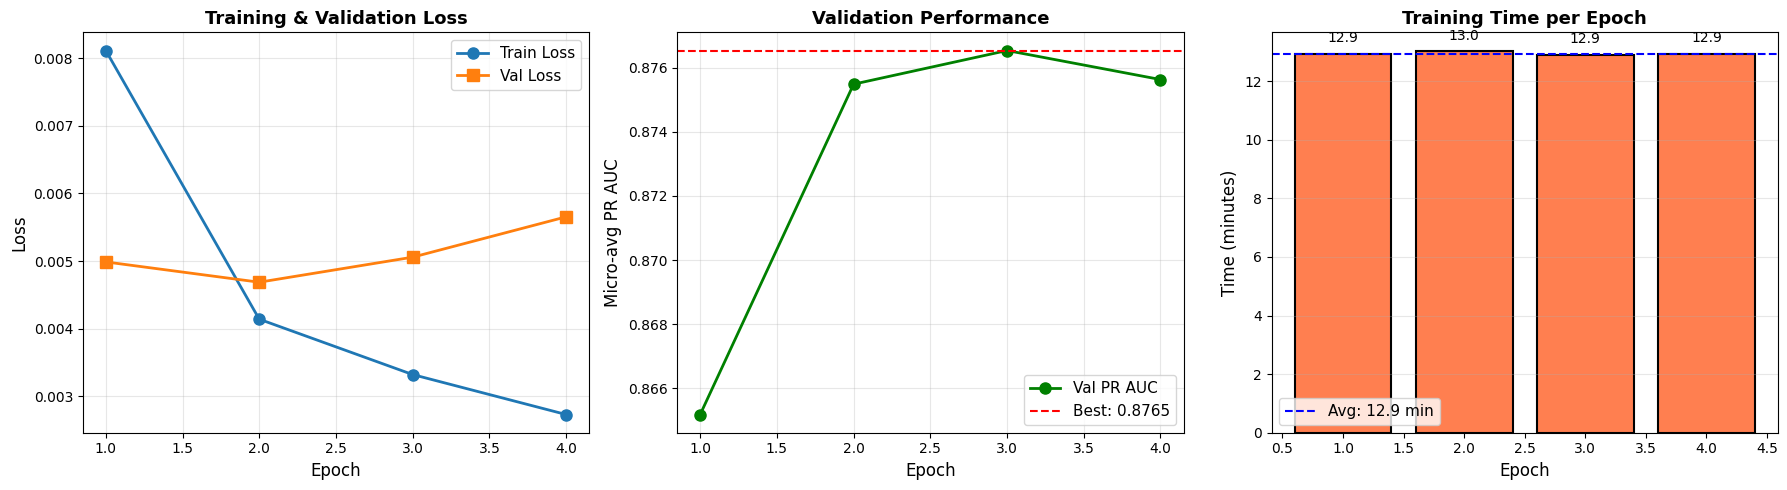

✓ Plot saved as 'training_history.png'


In [25]:
# Plot Training History
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
ax = axes[0]
epochs = range(1, len(history['train_loss']) + 1)
ax.plot(epochs, history['train_loss'], 'o-', label='Train Loss', linewidth=2, markersize=8)
ax.plot(epochs, history['val_loss'], 's-', label='Val Loss', linewidth=2, markersize=8)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# PR AUC curve
ax = axes[1]
ax.plot(epochs, history['val_pr_auc'], 'o-', label='Val PR AUC', 
        color='green', linewidth=2, markersize=8)
ax.axhline(y=best_val_pr_auc, color='red', linestyle='--', 
           label=f'Best: {best_val_pr_auc:.4f}', linewidth=1.5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Micro-avg PR AUC', fontsize=12)
ax.set_title('Validation Performance', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Epoch times
ax = axes[2]
epoch_times_min = [t / 60 for t in history['epoch_times']]
bars = ax.bar(epochs, epoch_times_min, color='coral', edgecolor='black', linewidth=1.5)
ax.axhline(y=np.mean(epoch_times_min), color='blue', linestyle='--', 
           label=f'Avg: {np.mean(epoch_times_min):.1f} min', linewidth=1.5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Time (minutes)', fontsize=12)
ax.set_title('Training Time per Epoch', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for bar, time_val in zip(bars, epoch_times_min):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{time_val:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot saved as 'training_history.png'")

In [26]:
# Load best v7 checkpoint.
# The `config` field in the checkpoint is authoritative for reconstructing
# the model — do NOT rely on the current in-memory CONFIG to match, since
# you may be loading a prior run.
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded {checkpoint.get('notebook_version', 'unknown')} from {best_model_path}")
print(f"  Epoch: {checkpoint['epoch'] + 1}")
print(f"  Val PR AUC: {checkpoint['val_pr_auc']:.4f}")

✓ Loaded v7-shared-trunk from best_model_v7.pt
  Epoch: 3
  Val PR AUC: 0.8765


In [27]:
# Test set evaluation - v7
# Same variable-length tokenization + length-bucketed batching as training.
# test_labels.csv has -1 for rows Kaggle excluded from scoring; filter them.
#
# RESUME GUARD: if test_inference_v7.npz exists from a prior run, we
# load all_test_preds / all_test_labels / valid_test_df['id'] from it
# and skip tokenization + inference (which costs ~15 min on the full
# 63k valid test set). To force re-inference, delete test_inference_v7.npz.
_test_npz = 'test_inference_v7.npz'

if _os.path.exists(_test_npz):
    print(f"\n✓ Loading cached test inference from {_test_npz}")
    _cache = np.load(_test_npz, allow_pickle=False)
    all_test_preds = _cache['all_test_preds']
    all_test_labels = _cache['all_test_labels']
    # Minimal valid_test_df reconstruction — downstream cells only need 'id'.
    valid_test_df = pd.DataFrame({'id': _cache['valid_test_ids']})
    print(f"  Predictions shape: {all_test_preds.shape}")
    print(f"  Labels shape:      {all_test_labels.shape}")
    print(f"  To force re-inference, delete {_test_npz}.")
elif _os.path.exists('test_predictions_v7.csv'):
    # Fast fallback: rebuild npz from the already-saved predictions CSV so
    # we do not have to re-run the 15-min test inference on first resume.
    print("\n✓ Rebuilding test arrays from test_predictions_v7.csv (no GPU needed)")
    _pred_df = pd.read_csv('test_predictions_v7.csv')
    valid_mask = (test_labels_df[labels_list] != -1).all(axis=1)
    _labels_df = test_labels_df.loc[valid_mask, ['id'] + labels_list].reset_index(drop=True)
    _merged = _labels_df.merge(_pred_df, on='id', how='inner', suffixes=('_true', '_pred'))
    all_test_labels = _merged[[f'{l}_true' for l in labels_list]].values.astype(np.float32)
    all_test_preds = _merged[[f'{l}_pred' for l in labels_list]].values.astype(np.float32)
    valid_test_df = _merged[['id']].copy()
    np.savez(_test_npz,
             all_test_preds=all_test_preds,
             all_test_labels=all_test_labels,
             valid_test_ids=valid_test_df['id'].values)
    print(f"  Reconstructed {len(all_test_preds):,} rows and cached to {_test_npz}")
else:
    print("\nPreparing test set...")

    valid_mask = (test_labels_df[labels_list] != -1).all(axis=1)
    valid_test_labels_arr = test_labels_df.loc[valid_mask, labels_list].values
    valid_test_df = test_df.loc[valid_mask].reset_index(drop=True)
    print(f"Valid test samples: {len(valid_test_df):,}")

    print("Tokenizing test data (variable-length)...")
    test_encoded = tokenizer(
        valid_test_df['comment_text'].tolist(),
        max_length=CONFIG['MAX_LENGTH'],
        truncation=True,
        padding=False,
        return_attention_mask=True,
    )

    test_dataset = ToxicCommentsDataset(
        test_encoded['input_ids'],
        test_encoded['attention_mask'],
        valid_test_labels_arr.astype(np.float32),
    )

    # Same bucketed sampler as validation — no shuffle, strict length sort.
    test_lengths = [len(x) for x in test_encoded['input_ids']]
    test_sampler = LengthBucketedBatchSampler(
        lengths=test_lengths,
        batch_size=96,  # inference batches can go larger (no backward pass)
        bucket_multiplier=CONFIG['BUCKET_MULTIPLIER'],
        shuffle=False,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_sampler=test_sampler,
        num_workers=0,
        pin_memory=_pin,
        collate_fn=dynamic_pad_collate,
    )

    print("Generating predictions...")
    model.eval()
    # test_sampler preserves bucket ordering; we need original row order to
    # align with `valid_test_df`. Collect (orig_index, probs) pairs and sort
    # after, so the test_predictions CSV matches the test_df row order.
    all_preds_indexed = []
    all_labels_indexed = []

    # Rebuild an iterator that also exposes sample indices.
    for batch_indices in test_sampler:
        batch = [test_dataset[i] for i in batch_indices]
        batch = dynamic_pad_collate(batch)
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)

        with torch.no_grad():
            if CONFIG['USE_FP16'] and torch.cuda.is_available():
                with torch.cuda.amp.autocast():
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs).cpu().numpy()
        labels_np = labels.cpu().numpy()
        for local_i, orig_i in enumerate(batch_indices):
            all_preds_indexed.append((orig_i, probs[local_i]))
            all_labels_indexed.append((orig_i, labels_np[local_i]))

    # Sort back into original test-set order.
    all_preds_indexed.sort(key=lambda t: t[0])
    all_labels_indexed.sort(key=lambda t: t[0])
    all_test_preds = np.vstack([p for _, p in all_preds_indexed])
    all_test_labels = np.vstack([l for _, l in all_labels_indexed])

    # Cache results so subsequent runs can skip this ~15-min step.
    np.savez(
        _test_npz,
        all_test_preds=all_test_preds,
        all_test_labels=all_test_labels,
        valid_test_ids=valid_test_df['id'].values,
    )
    print(f"✓ Predictions complete — cached to {_test_npz}")



Preparing test set...
Valid test samples: 63,978
Tokenizing test data (variable-length)...
Generating predictions...
✓ Predictions complete!


In [28]:
# Comprehensive Test Metrics
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    accuracy_score,
    precision_recall_fscore_support
)

print("\n" + "═" * 70)
print(" " * 23 + "TEST SET RESULTS")
print("═" * 70)

threshold = 0.5
y_pred_binary = (all_test_preds >= threshold).astype(int)

print("\nPer-Label Metrics (threshold=0.5):")
print("─" * 70)
print(f"{'Label':<15} {'PR AUC':>8} {'ROC AUC':>8} {'Prec':>7} {'Recall':>7} {'F1':>7}")
print("─" * 70)

for i, label in enumerate(labels_list):
    pr_auc = average_precision_score(all_test_labels[:, i], all_test_preds[:, i])
    roc_auc = roc_auc_score(all_test_labels[:, i], all_test_preds[:, i])
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_test_labels[:, i], y_pred_binary[:, i], average='binary', zero_division=0
    )
    
    print(f"{label:<15} {pr_auc:8.4f} {roc_auc:8.4f} {precision:7.4f} {recall:7.4f} {f1:7.4f}")

micro_pr_auc = average_precision_score(all_test_labels, all_test_preds, average="micro")
exact_match = accuracy_score(all_test_labels, y_pred_binary)

print("─" * 70)
print(f"\nOverall Metrics:")
print(f"  Micro-average PR AUC: {micro_pr_auc:.4f}")
print(f"  Exact Match Ratio:    {exact_match:.4f}")
print("═" * 70)


══════════════════════════════════════════════════════════════════════
                       TEST SET RESULTS
══════════════════════════════════════════════════════════════════════

Per-Label Metrics (threshold=0.5):
──────────────────────────────────────────────────────────────────────
Label             PR AUC  ROC AUC    Prec  Recall      F1
──────────────────────────────────────────────────────────────────────
toxic             0.8063   0.9727  0.4523  0.9532  0.6135
severe_toxic      0.3443   0.9899  0.2516  0.7657  0.3787
obscene           0.8050   0.9815  0.4943  0.9054  0.6395
threat            0.6026   0.9973  0.4250  0.8057  0.5565
insult            0.7918   0.9813  0.5090  0.8789  0.6447
identity_hate     0.6779   0.9920  0.4543  0.8034  0.5804
──────────────────────────────────────────────────────────────────────

Overall Metrics:
  Micro-average PR AUC: 0.7575
  Exact Match Ratio:    0.8337
══════════════════════════════════════════════════════════════════════


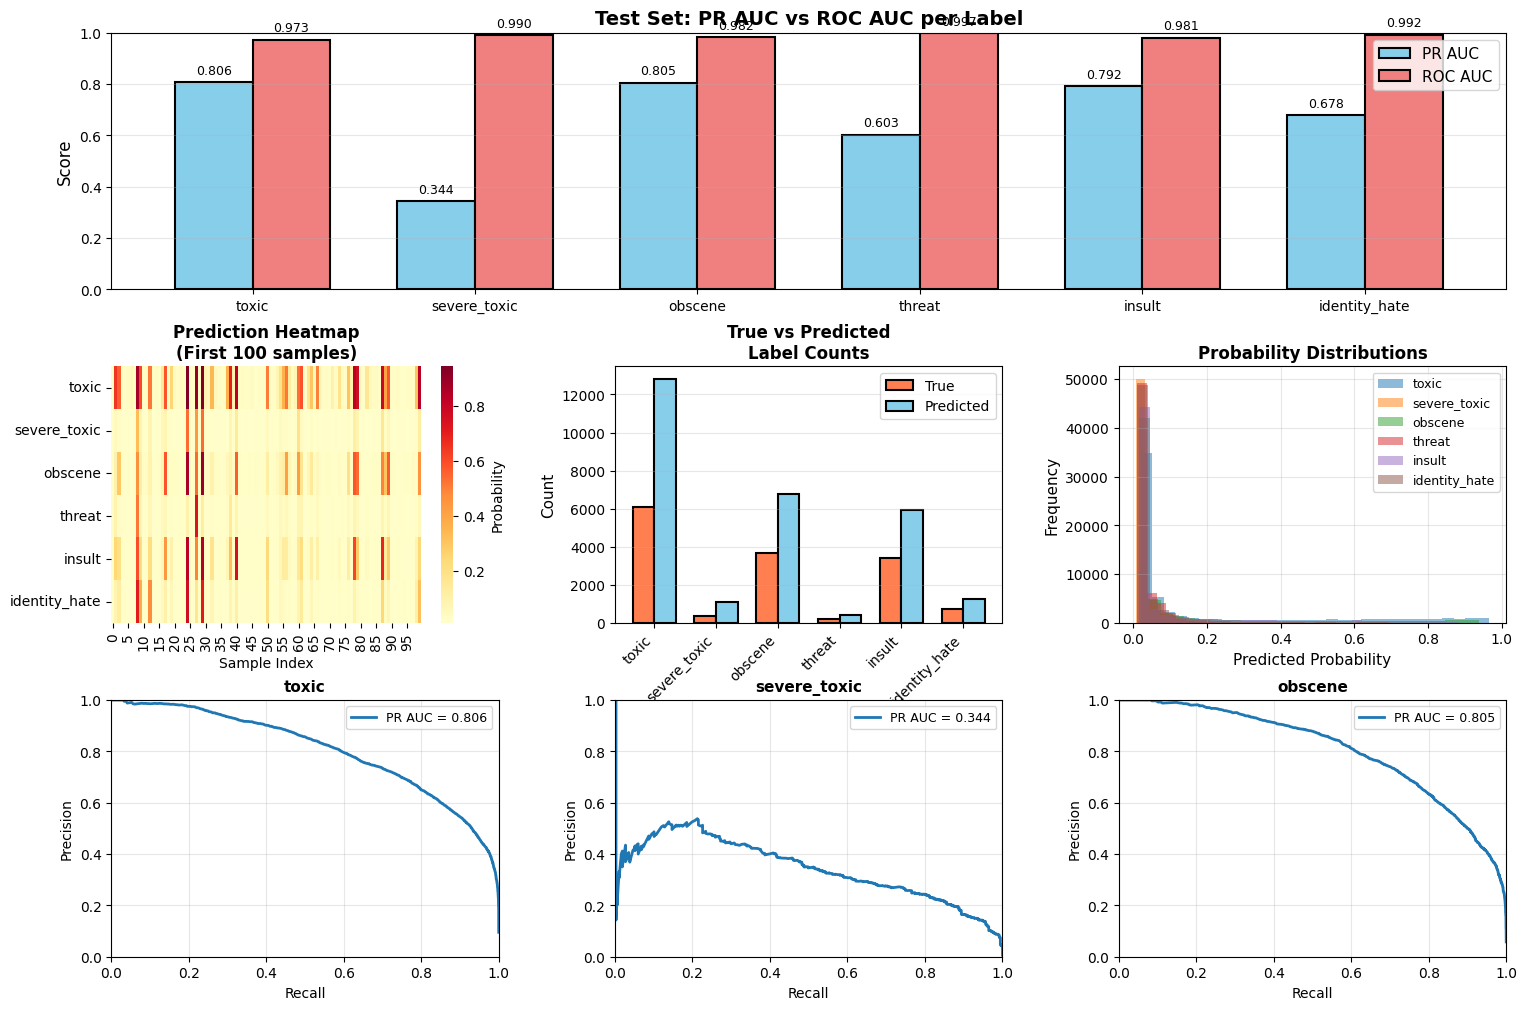


✓ Visualization saved as 'test_results_comprehensive.png'


In [29]:
# Visualize Test Results
import matplotlib.pyplot as plt
import seaborn as sns

pr_aucs_test = {label: average_precision_score(all_test_labels[:, i], all_test_preds[:, i]) 
                for i, label in enumerate(labels_list)}
roc_aucs_test = {label: roc_auc_score(all_test_labels[:, i], all_test_preds[:, i]) 
                 for i, label in enumerate(labels_list)}

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. PR AUC comparison
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(labels_list))
width = 0.35
bars1 = ax1.bar(x - width/2, list(pr_aucs_test.values()), width, 
                label='PR AUC', color='skyblue', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, list(roc_aucs_test.values()), width, 
                label='ROC AUC', color='lightcoral', edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Test Set: PR AUC vs ROC AUC per Label', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels_list, rotation=0)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Prediction heatmap
ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(all_test_preds[:100, :].T, cmap='YlOrRd', yticklabels=labels_list,
            cbar_kws={'label': 'Probability'}, ax=ax2)
ax2.set_title('Prediction Heatmap\n(First 100 samples)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sample Index')

# 3. True vs Predicted counts
ax3 = fig.add_subplot(gs[1, 1])
true_counts = all_test_labels.sum(axis=0)
pred_counts = y_pred_binary.sum(axis=0)
x_pos = np.arange(len(labels_list))
width = 0.35
ax3.bar(x_pos - width/2, true_counts, width, label='True', 
        color='coral', edgecolor='black', linewidth=1.5)
ax3.bar(x_pos + width/2, pred_counts, width, label='Predicted', 
        color='skyblue', edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('True vs Predicted\nLabel Counts', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(labels_list, rotation=45, ha='right')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Probability distributions
ax4 = fig.add_subplot(gs[1, 2])
for i, label in enumerate(labels_list):
    ax4.hist(all_test_preds[:, i], bins=30, alpha=0.5, label=label)
ax4.set_xlabel('Predicted Probability', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Probability Distributions', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 5-10. Per-label PR curves
from sklearn.metrics import precision_recall_curve

for idx, label in enumerate(labels_list):
    ax = fig.add_subplot(gs[2, idx % 3])
    precision, recall, _ = precision_recall_curve(all_test_labels[:, idx], all_test_preds[:, idx])
    pr_auc = pr_aucs_test[label]
    
    ax.plot(recall, precision, linewidth=2, label=f'PR AUC = {pr_auc:.3f}')
    ax.set_xlabel('Recall', fontsize=10)
    ax.set_ylabel('Precision', fontsize=10)
    ax.set_title(f'{label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    if idx >= 2:
        break

plt.savefig('test_results_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'test_results_comprehensive.png'")

In [30]:
# Inference utilities — v7
#
# Two paths:
#   predict_text  — single-window, for the common case (<= MAX_LENGTH tokens).
#   predict_long  — sliding-window aggregator for comments longer than
#                   MAX_LENGTH. Splits into overlapping windows of size
#                   MAX_LENGTH, stride = MAX_LENGTH/2, runs each, and
#                   takes the elementwise max of the per-label logits
#                   across windows. "Max" is the right aggregation for
#                   toxicity: a long comment is toxic if ANY window is.
#
# WHY THIS ONLY LIVES AT INFERENCE: at training time, chunking would
# duplicate the comment-level label onto every chunk — even chunks that
# don't contain the toxic span. That's label noise. At inference we
# don't need a label; we just need the model to "see" all the tokens.
def _forward_probs(ids_tensor, mask_tensor, model, device, use_fp16):
    ids = ids_tensor.to(device)
    mask = mask_tensor.to(device)
    if use_fp16 and torch.cuda.is_available():
        with torch.cuda.amp.autocast():
            logits = model(input_ids=ids, attention_mask=mask)
    else:
        logits = model(input_ids=ids, attention_mask=mask)
    return torch.sigmoid(logits).cpu().numpy()  # [B, num_labels]


def predict_text(text, model, tokenizer, device, max_length=None, use_fp16=False):
    """Single-window toxicity prediction. Truncates to max_length."""
    max_length = max_length or CONFIG['MAX_LENGTH']
    model.eval()
    enc = tokenizer(
        text, max_length=max_length, truncation=True,
        padding=False, return_tensors='pt',
    )
    with torch.no_grad():
        probs = _forward_probs(enc['input_ids'], enc['attention_mask'], model, device, use_fp16)[0]
    return dict(zip(labels_list, probs))


def predict_long(text, model, tokenizer, device, window=None, stride=None, use_fp16=False):
    """
    Sliding-window prediction for long comments.
    Tokenizes without truncation, slides a `window`-token window with
    step `stride`, runs each window, aggregates with elementwise max.
    """
    window = window or CONFIG['MAX_LENGTH']
    stride = stride or (window // 2)
    model.eval()

    # Full tokenization (no truncation) so we can window it ourselves.
    full = tokenizer(text, truncation=False, padding=False, add_special_tokens=True)
    input_ids = full['input_ids']
    attn_mask = full['attention_mask']
    n = len(input_ids)

    if n <= window:
        return predict_text(text, model, tokenizer, device, window, use_fp16)

    # Build windows. Each window keeps [CLS] at position 0 so the
    # [CLS]-based pooling in the model still works; [CLS] id is input_ids[0].
    cls_id = input_ids[0]
    sep_id = input_ids[-1]  # [SEP] at the very end
    body = input_ids[1:-1]  # content tokens only
    body_mask = attn_mask[1:-1]

    content_span = window - 2  # reserve slots for [CLS] and [SEP]
    windows_ids, windows_mask = [], []
    i = 0
    while i < len(body):
        chunk_ids = [cls_id] + body[i:i + content_span] + [sep_id]
        chunk_mask = [1] + body_mask[i:i + content_span] + [1]
        windows_ids.append(torch.tensor(chunk_ids, dtype=torch.long))
        windows_mask.append(torch.tensor(chunk_mask, dtype=torch.long))
        if i + content_span >= len(body):
            break
        i += stride

    ids_batch = pad_sequence(windows_ids, batch_first=True, padding_value=0)
    mask_batch = pad_sequence(windows_mask, batch_first=True, padding_value=0)

    with torch.no_grad():
        per_window = _forward_probs(ids_batch, mask_batch, model, device, use_fp16)  # [W, 6]
    aggregated = per_window.max(axis=0)  # take the loudest window per label
    return dict(zip(labels_list, aggregated))


# Sanity-check on a mix of short/long examples. The last one is padded
# long to exercise the sliding-window path.
examples = [
    "This is a great article, very informative and well-written!",
    "You are an idiot and your opinion is garbage.",
    "I will find you and make you pay for this!",
    "I respectfully disagree with your point of view.",
    "F*** off you stupid piece of s***!",
    ("Long comment demo. " * 80) + "You absolute moron, I hope you get fired.",
]

print("\n" + "═" * 80)
print(" " * 28 + "CUSTOM TEXT PREDICTIONS")
print("═" * 80)
for i, text in enumerate(examples, 1):
    # Route long comments through the sliding-window path automatically.
    toks = tokenizer(text, truncation=False, add_special_tokens=True)['input_ids']
    is_long = len(toks) > CONFIG['MAX_LENGTH']
    preds = (predict_long if is_long else predict_text)(
        text, model, tokenizer, device, use_fp16=CONFIG['USE_FP16']
    )

    shown = text if len(text) < 80 else text[:77] + "..."
    print(f"\n[{i}] ({'long/windowed' if is_long else 'single-window'}) '{shown}'")
    print("─" * 80)
    max_prob = max(preds.values())
    verdict = '🚨 TOXIC' if max_prob >= 0.5 else '✅ SAFE'
    print(f"Overall: {verdict} (max prob: {max_prob:.4f})")
    for label, prob in sorted(preds.items(), key=lambda x: x[1], reverse=True):
        bar = '█' * int(prob * 40) + '░' * (40 - int(prob * 40))
        marker = '⚠' if prob >= 0.5 else ' '
        print(f"  {marker} {label:15s} {prob:.4f} |{bar}|")
print("\n" + "═" * 80)


════════════════════════════════════════════════════════════════════════════════
                            CUSTOM TEXT PREDICTIONS
════════════════════════════════════════════════════════════════════════════════

[1] (single-window) 'This is a great article, very informative and well-written!'
────────────────────────────────────────────────────────────────────────────────
Overall: ✅ SAFE (max prob: 0.0411)
    toxic           0.0411 |█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
    insult          0.0239 |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
    identity_hate   0.0211 |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
    obscene         0.0210 |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
    threat          0.0204 |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|
    severe_toxic    0.0171 |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░|

[2] (single-window) 'You are an idiot and your opinion is garbage.'
────────────────────────────────────────────────────────────────────────────────
Overall: 🚨 TOXIC

In [31]:
# Save predictions, history, and metrics — v7-tagged filenames so v6's
# artifacts aren't overwritten. Compare side-by-side with the v6 CSVs
# when judging whether the architecture changes landed.
test_pred_df = pd.DataFrame(all_test_preds, columns=labels_list)
test_pred_df['id'] = valid_test_df['id'].values
output_df = test_pred_df[['id'] + labels_list]
output_df.to_csv('test_predictions_v7.csv', index=False)
print("✓ Predictions saved to 'test_predictions_v7.csv'")

history_df = pd.DataFrame({
    'epoch': range(1, len(history['train_loss']) + 1),
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'val_pr_auc': history['val_pr_auc'],
    'epoch_time_min': [t/60 for t in history['epoch_times']],
})
history_df.to_csv('training_history_v7.csv', index=False)
print("✓ Training history saved to 'training_history_v7.csv'")

metrics = {
    'notebook_version': 'v7-shared-trunk',
    'test_micro_pr_auc': micro_pr_auc,
    'test_exact_match': exact_match,
    'val_best_pr_auc': best_val_pr_auc,
    'total_training_time_hours': sum(history['epoch_times']) / 3600,
    'config': CONFIG,
}

import json
with open('final_metrics_v7.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("✓ Final metrics saved to 'final_metrics_v7.json'")

print("\n" + "═" * 70)
print(" " * 28 + "ALL DONE!")
print("═" * 70)

✓ Predictions saved to 'test_predictions_v7.csv'
✓ Training history saved to 'training_history_v7.csv'
✓ Final metrics saved to 'final_metrics_v7.json'

══════════════════════════════════════════════════════════════════════
                            ALL DONE!
══════════════════════════════════════════════════════════════════════


## Summary — v7 changelog

### Fixes over v6

1. **Shared trunk + single `Linear(H, 6)` classifier** replaces the six-independent-MLP architecture. Head-block parameters cut ~6×; correlated labels share the learned representation instead of duplicating it.
2. **`MAX_LENGTH = 192` + length-bucketed batching + dynamic padding.** Profiling the first v7 attempt (`MAX_LENGTH=256`, random shuffle) showed 97% of batches padded to the cap because of the heavy tail. Switching to a SortishSampler-style bucketed batch sampler means most batches pad to ~50–80 tokens. Expected ~2–3× speedup over the first v7 attempt.
3. **Focal loss only, no `pos_weight`.** Removes the v6 double-correction that was making rare-class gradients explode. Per-class `alpha` derived from positive rate (clamped to [0.25, 0.75]).
4. **`FREEZE_LAYERS = 2`** (was 3). Keeps ~90% trainable capacity.
5. **Sliding-window inference (`predict_long`)** for comments beyond `MAX_LENGTH`.
6. **Hardware knobs**: batch 64 (fits easily with bucketing), `non_blocking=True` on copies, `torch.set_float32_matmul_precision('high')`.

### Files produced

- `best_model_v7.pt` — checkpoint with model, optimizer, scheduler, val metrics, and the full CONFIG used.
- `test_predictions_v7.csv` — per-sample sigmoid outputs, in original test-row order.
- `training_history_v7.csv` / `training_history.png` — per-epoch loss + PR AUC + runtime.
- `test_results_comprehensive.png` — per-label PR curves.
- `final_metrics_v7.json` — summary metrics + config.
- `preprocessed_data/train_v7_mlen192_full.pkl` / `val_v7_mlen192_full.pkl` — variable-length token cache.

### Targets to beat

| Metric | v6 (aborted, 1 epoch) | v7 first attempt (aborted 13%) | v7 target |
|---|---|---|---|
| Micro PR AUC | 0.035 | — | 0.55–0.65 |
| `threat` PR AUC | 0.003 | — | 0.20–0.40 |
| `identity_hate` PR AUC | 0.008 | — | 0.25–0.45 |
| Epoch time | ~1.8 min (ebm-only) / ~30 min (full v6) | ~44 min | ~12–15 min |

### If accuracy still stalls

Next levers in order of expected ROI:
1. Switch base to `unitary/toxic-bert` or `roberta-base` (DistilBERT ceiling ≈ 0.65 micro PR AUC).
2. Fine-tune all 6 layers (`FREEZE_LAYERS=0`) with lower learning rate (1e-5).
3. Class-conditional threshold tuning on the val set.
4. Head+tail truncation at training time for the long-comment tail.


## Per-class threshold tuning (post-hoc)

Default `threshold=0.5` is not F1-optimal under focal loss because focal
compresses logit magnitudes asymmetrically. Below we:

1. Collect sigmoid probabilities on the **validation** set (no re-training).
2. For each label, search the PR curve for the F1-optimal threshold on val.
3. Apply those thresholds to the **test** set and report P/R/F1 side-by-side
   with the 0.5-threshold baseline.

Important: thresholds are tuned on val, not test — this is the correct
methodology (tuning on test would be data leakage). We expect macro F1 to
improve without touching the underlying model.

Existing artifacts (`best_model_v7.pt`, `test_predictions_v7.csv`,
`final_metrics_v7.json`, `training_history_v7.csv`) are **preserved**; new
outputs land in `tuned_thresholds_v7.json` and `test_predictions_v7_tuned.csv`.


In [5]:
# Collect validation probabilities (no gradient, reuses the loaded best model)
# Cached to val_inference_v7.npz so repeated runs of the tuning block are cheap.
# Self-contained cache-hit path: import numpy and declare labels_list if kernel was
# just restarted and the user is jumping straight to the tuning block.
import numpy as np
from tqdm.auto import tqdm
import os as _os

if 'labels_list' not in dir():
    labels_list = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

_val_npz = 'val_inference_v7.npz'

if _os.path.exists(_val_npz):
    _d = np.load(_val_npz)
    val_probs_arr = _d['val_probs']
    val_true_arr = _d['val_true']
    print(f"✓ Loaded cached val inference from {_val_npz}")
    print(f"  Val probs:  {val_probs_arr.shape}")
    print(f"  Val labels: {val_true_arr.shape}")
else:
    model.eval()
    val_probs_chunks = []
    val_true_chunks = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Val inference', leave=True):
            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            if CONFIG['USE_FP16'] and torch.cuda.is_available():
                with torch.cuda.amp.autocast():
                    logits = model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                logits = model(input_ids=input_ids, attention_mask=attention_mask)
            val_probs_chunks.append(torch.sigmoid(logits.float()).cpu().numpy())
            val_true_chunks.append(batch['labels'].numpy())

    val_probs_arr = np.concatenate(val_probs_chunks, axis=0)
    val_true_arr = np.concatenate(val_true_chunks, axis=0)
    np.savez(_val_npz, val_probs=val_probs_arr, val_true=val_true_arr)
    print(f"Val probs:  {val_probs_arr.shape}")
    print(f"Val labels: {val_true_arr.shape}")
    print(f"✓ Cached to {_val_npz}")

print(f"Val positive rates (sanity): " + ", ".join(
    f"{lab}={val_true_arr[:, i].mean():.4f}" for i, lab in enumerate(labels_list)
))


✓ Loaded cached val inference from val_inference_v7.npz
  Val probs:  (15958, 6)
  Val labels: (15958, 6)
Val positive rates (sanity): toxic=0.0956, severe_toxic=0.0090, obscene=0.0518, threat=0.0026, insult=0.0488, identity_hate=0.0083


In [6]:
# Per-label F1-optimal threshold on validation
# RARE-LABEL FLOOR: when val positives < MIN_POSITIVES_FOR_TUNING, the PR curve is
# too noisy for a reliable F1-optimal pick. In v7, `threat` had only 48 val positives;
# its naive val-optimal threshold (0.455) regressed −0.027 F1 on test. Floor at 0.5.
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

MIN_POSITIVES_FOR_TUNING = 100

best_thresholds = {}
val_positive_counts = {}
floored_labels = []

print('\nThreshold tuning on VALIDATION (F1-optimal, floored at 0.5 when val pos < {}):'.format(MIN_POSITIVES_FOR_TUNING))
print('─' * 96)
print(f"{'Label':<16}{'ValPos':>8}{'Thr*raw':>10}{'Thr*use':>10}{'Val P*':>9}{'Val R*':>9}{'Val F1*':>10}{'F1@0.5':>10}{'ΔF1':>10}")
print('─' * 96)

for i, label in enumerate(labels_list):
    y_true = val_true_arr[:, i].astype(int)
    y_prob = val_probs_arr[:, i]
    n_pos = int(y_true.sum())
    val_positive_counts[label] = n_pos

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
    if len(f1s) == 0:
        best_thresholds[label] = 0.5
        continue
    best_idx = int(np.argmax(f1s))
    thr_raw = float(thresholds[best_idx])
    f1_star = float(f1s[best_idx])
    p_star = float(precisions[best_idx])
    r_star = float(recalls[best_idx])

    # Apply floor for rare labels
    if n_pos < MIN_POSITIVES_FOR_TUNING:
        thr_use = max(thr_raw, 0.5)
        if thr_use != thr_raw:
            floored_labels.append(label)
    else:
        thr_use = thr_raw

    f1_at_05 = f1_score(y_true, (y_prob >= 0.5).astype(int), zero_division=0)

    best_thresholds[label] = thr_use
    flag = ' *' if label in floored_labels else ''
    print(f"{label:<16}{n_pos:>8d}{thr_raw:>10.3f}{thr_use:>10.3f}{p_star:>9.3f}{r_star:>9.3f}{f1_star:>10.3f}{f1_at_05:>10.3f}{f1_star - f1_at_05:>+10.3f}{flag}")

print('─' * 96)
if floored_labels:
    print(f"\n* Floored at 0.5 (val positives < {MIN_POSITIVES_FOR_TUNING}): {', '.join(floored_labels)}")

print('\nChosen thresholds:')
for lab, thr in best_thresholds.items():
    marker = ' (floored)' if lab in floored_labels else ''
    print(f"  {lab:<16}: {thr:.3f}{marker}")



Threshold tuning on VALIDATION (F1-optimal, floored at 0.5 when val pos < 100):
────────────────────────────────────────────────────────────────────────────────────────────────
Label             ValPos   Thr*raw   Thr*use   Val P*   Val R*   Val F1*    F1@0.5       ΔF1
────────────────────────────────────────────────────────────────────────────────────────────────
toxic               1525     0.628     0.628    0.855    0.809     0.831     0.803    +0.028
severe_toxic         143     0.553     0.553    0.520    0.545     0.532     0.494    +0.039
obscene              826     0.687     0.687    0.877    0.814     0.844     0.814    +0.030
threat                42     0.455     0.500    0.406    0.667     0.505     0.481    +0.024 *
insult               778     0.611     0.611    0.759    0.794     0.776     0.756    +0.020
identity_hate        132     0.597     0.597    0.629    0.591     0.609     0.542    +0.068
────────────────────────────────────────────────────────────────────────

In [7]:
# Apply tuned thresholds to the TEST set — report side-by-side with 0.5 baseline
# Self-contained after kernel restart: reimport libs and rehydrate test arrays from
# test_inference_v7.npz if not in scope (cell 15 produces this cache).
import numpy as np
import pandas as pd
import os as _os
from sklearn.metrics import precision_score, recall_score, f1_score

if 'all_test_preds' not in dir() or 'all_test_labels' not in dir() or 'valid_test_df' not in dir():
    _test_npz = 'test_inference_v7.npz'
    if not _os.path.exists(_test_npz):
        raise RuntimeError(
            f"{_test_npz} not found. Run cell 15 (test inference) first — it will "
            "load from test_predictions_v7.csv if present, otherwise run full inference."
        )
    _td = np.load(_test_npz, allow_pickle=True)
    # npz keys match what cell 15 writes: all_test_preds / all_test_labels / valid_test_ids
    all_test_preds = _td['all_test_preds']
    all_test_labels = _td['all_test_labels']
    valid_test_df = pd.DataFrame({'id': _td['valid_test_ids']})
    print(f"✓ Rehydrated test arrays from {_test_npz} ({all_test_preds.shape})")

print('\n' + '═' * 82)
print(' ' * 20 + 'TEST SET — TUNED THRESHOLDS vs 0.5')
print('═' * 82)
print(f"{'Label':<16}{'Thr*':>7}{'P*':>8}{'R*':>8}{'F1*':>8}  |  {'P@.5':>7}{'R@.5':>8}{'F1@.5':>8}")
print('─' * 82)

tuned_per_label = {}
f1_tuned_list = []
f1_05_list = []

for i, label in enumerate(labels_list):
    thr = best_thresholds[label]
    y_true = all_test_labels[:, i].astype(int)
    y_prob = all_test_preds[:, i]

    y_pred_tuned = (y_prob >= thr).astype(int)
    y_pred_05 = (y_prob >= 0.5).astype(int)

    p_t = precision_score(y_true, y_pred_tuned, zero_division=0)
    r_t = recall_score(y_true, y_pred_tuned, zero_division=0)
    f_t = f1_score(y_true, y_pred_tuned, zero_division=0)

    p_5 = precision_score(y_true, y_pred_05, zero_division=0)
    r_5 = recall_score(y_true, y_pred_05, zero_division=0)
    f_5 = f1_score(y_true, y_pred_05, zero_division=0)

    tuned_per_label[label] = {
        'threshold': float(thr),
        'test_precision_tuned': float(p_t),
        'test_recall_tuned': float(r_t),
        'test_f1_tuned': float(f_t),
        'test_precision_at_0.5': float(p_5),
        'test_recall_at_0.5': float(r_5),
        'test_f1_at_0.5': float(f_5),
    }
    f1_tuned_list.append(f_t)
    f1_05_list.append(f_5)

    print(f"{label:<16}{thr:>7.3f}{p_t:>8.3f}{r_t:>8.3f}{f_t:>8.3f}  |  {p_5:>7.3f}{r_5:>8.3f}{f_5:>8.3f}")

macro_f1_tuned = float(np.mean(f1_tuned_list))
macro_f1_05 = float(np.mean(f1_05_list))

print('─' * 82)
print(f"{'MACRO F1':<16}{'':>7}{'':>8}{'':>8}{macro_f1_tuned:>8.3f}  |  {'':>7}{'':>8}{macro_f1_05:>8.3f}")
print(f"\nMacro F1 lift (tuned − 0.5):  {macro_f1_tuned - macro_f1_05:+.3f}")
print('═' * 82)

# ----- Save artifacts (new files; existing ones untouched) -----
tuned_payload = {
    'notebook_version': 'v7-shared-trunk',
    'method': 'per-class F1-optimal threshold tuned on validation set, floored at 0.5 for labels with <100 val positives',
    'min_positives_for_tuning': MIN_POSITIVES_FOR_TUNING,
    'val_positive_counts': val_positive_counts,
    'floored_labels': floored_labels,
    'thresholds': {lab: float(thr) for lab, thr in best_thresholds.items()},
    'per_label_test_metrics': tuned_per_label,
    'macro_f1_test_tuned': macro_f1_tuned,
    'macro_f1_test_at_0.5': macro_f1_05,
    'macro_f1_lift': macro_f1_tuned - macro_f1_05,
}

import json as _json
with open('tuned_thresholds_v7.json', 'w') as f:
    _json.dump(tuned_payload, f, indent=2)
print("\n✓ Saved tuned_thresholds_v7.json")

# Test predictions CSV with both raw probs and tuned binary flags
tuned_pred_df = pd.DataFrame({'id': valid_test_df['id'].values})
for i, label in enumerate(labels_list):
    tuned_pred_df[f'{label}_prob'] = all_test_preds[:, i]
    tuned_pred_df[f'{label}_pred'] = (all_test_preds[:, i] >= best_thresholds[label]).astype(int)
tuned_pred_df.to_csv('test_predictions_v7_tuned.csv', index=False)
print("✓ Saved test_predictions_v7_tuned.csv")
print("  (original test_predictions_v7.csv and final_metrics_v7.json preserved)")


✓ Rehydrated test arrays from test_inference_v7.npz ((63978, 6))

══════════════════════════════════════════════════════════════════════════════════
                    TEST SET — TUNED THRESHOLDS vs 0.5
══════════════════════════════════════════════════════════════════════════════════
Label              Thr*      P*      R*     F1*  |     P@.5    R@.5   F1@.5
──────────────────────────────────────────────────────────────────────────────────
toxic             0.628   0.548   0.897   0.680  |    0.452   0.953   0.614
severe_toxic      0.553   0.320   0.575   0.411  |    0.252   0.766   0.379
obscene           0.687   0.672   0.771   0.718  |    0.494   0.905   0.639
threat            0.500   0.425   0.806   0.556  |    0.425   0.806   0.556
insult            0.611   0.649   0.769   0.704  |    0.509   0.879   0.645
identity_hate     0.597   0.544   0.673   0.601  |    0.454   0.803   0.580
──────────────────────────────────────────────────────────────────────────────────
MACRO F1       